In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

# Step 1: Load CSV directly
df = pd.read_csv('twitter_validation.csv')

# Step 2: Check available columns
print("Available columns:", df.columns)


Available columns: Index(['3364', 'Facebook', 'Irrelevant',
       'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣'],
      dtype='object')


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

# Step 1: Load CSV file directly
df = pd.read_csv('twitter_validation.csv')

# Step 2: Check available columns
print("Available columns:", df.columns)

# Step 3: Rename the column that contains text (replace 'message' with the actual column name if different)
# For example, if your column is called 'Tweet', update it as below:
df.rename(columns={'message': 'text'}, inplace=True)

Available columns: Index(['3364', 'Facebook', 'Irrelevant',
       'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣'],
      dtype='object')


In [12]:
def get_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return polarity, 'Positive'
    elif polarity < 0:
        return polarity, 'Negative'
    else:
        return polarity, 'Neutral'



In [23]:
df[['polarity', 'sentiment']] = df['text'].apply(lambda x: pd.Series(get_sentiment(x)))

In [24]:
print("Columns after sentiment analysis:", df.columns)

Columns after sentiment analysis: Index(['index', 'platform', 'irrelevant', 'text', 'polarity', 'sentiment'], dtype='object')


<ipython-input-25-068129409efd>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='pastel')


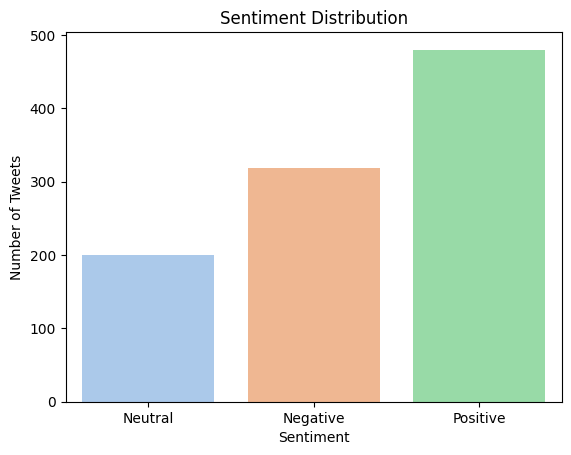

In [25]:
sns.countplot(x='sentiment', data=df, palette='pastel')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()